In [37]:
import torch
import numpy as np
import pandas as pd
import Plotting_IQR
import matplotlib.pyplot as plt
from Plotting_IQR import plot_distribution, get_training_data, plot_pfn_variance_surface
from pfn_evaluate import eval_pfn
import pfns4bo
from pfns4bo.scripts.acquisition_functions import TransformerBOMethod

In [38]:
# Load data
file_path = "results_BL_150/run_20260727_005330/baseline_metrics.pt"
metrics = torch.load(file_path)

file_path = "results_BL_150/run_20260727_005330/experimental_results.pt"
data = torch.load(file_path)

In [39]:
# metrics = {
#        "regret": torch.zeros((n_dims, n_methods, n_repeats, N_iters)),
#        "pred_error": torch.zeros((n_dims, 2, n_repeats, N_iters)), # GP & PFN only
#        "rank_of_method": torch.zeros((n_dims, n_methods, n_repeats, N_iters)),
#        "spearman_gp_pfn": torch.zeros((n_dims, N_iters)),
#        "spearman_gp_rand": torch.zeros((n_dims, N_iters)),
#        "spearman_pfn_rand": torch.zeros((n_dims, N_iters))
#    }
regret = metrics["regret"]
model_error = metrics["pred_error"]
rank = metrics["rank_of_method"]

In [40]:
# Regret Curve

# Get shape
n_dims, n_methods, n_repeats, N = regret.shape
print(regret.shape)

# Separate by dim
regret_2d = regret[0, :, :, :]
regret_5d = regret[1, :, :, :]
regret_10d = regret[2, :, :, :]

torch.Size([3, 3, 21, 150])


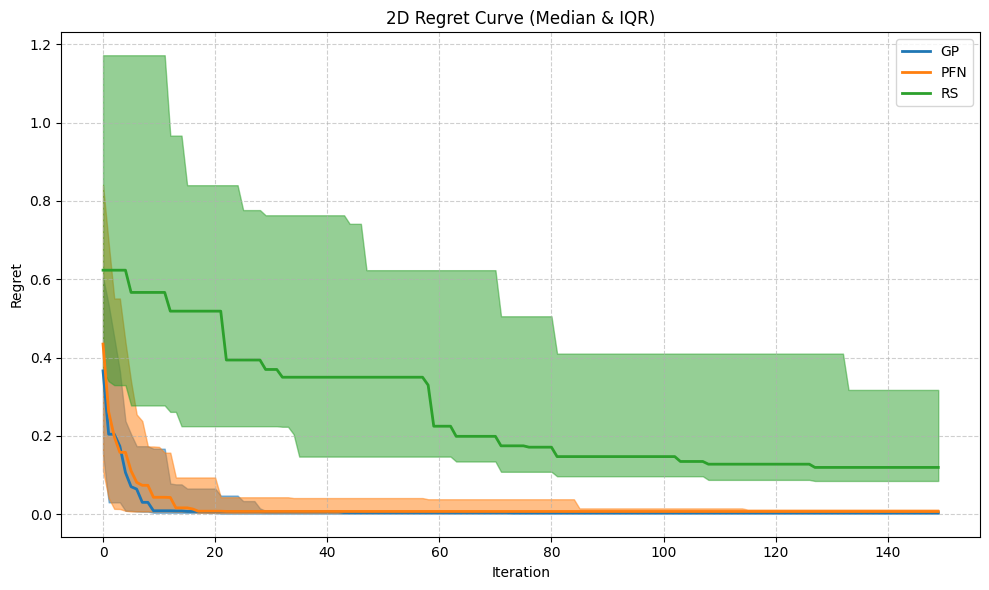

In [33]:
# Set up data dict
regret_data = {
    'GP': regret_2d[0, :, :],
    'PFN': regret_2d[1, :, :],
    'RS': regret_2d[2, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="2D Regret Curve (Median & IQR)")

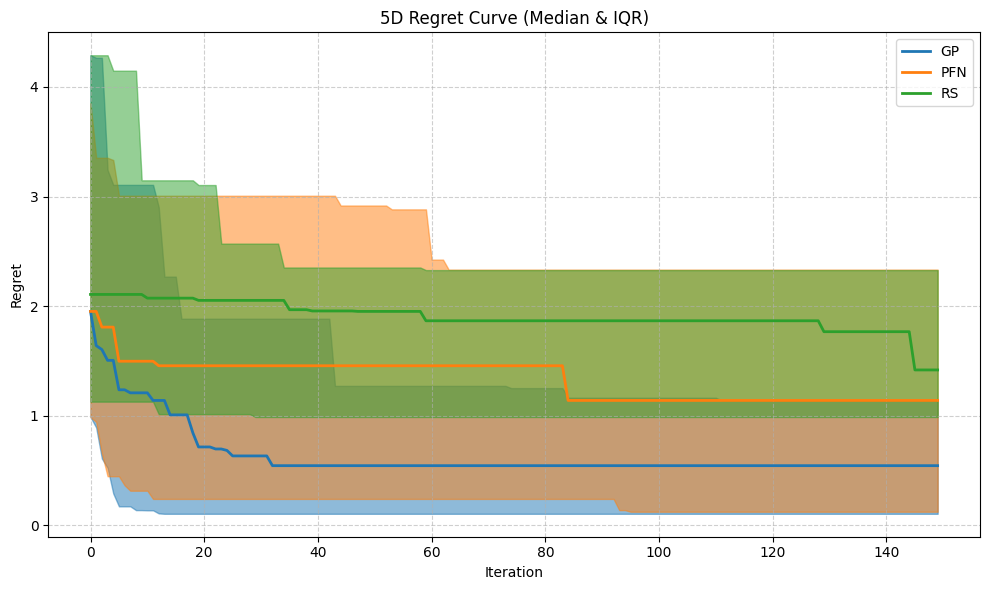

In [41]:
# Set up data dict
regret_data = {
    'GP': regret_5d[0, :, :],
    'PFN': regret_5d[1, :, :],
    'RS': regret_5d[2, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="5D Regret Curve (Median & IQR)")

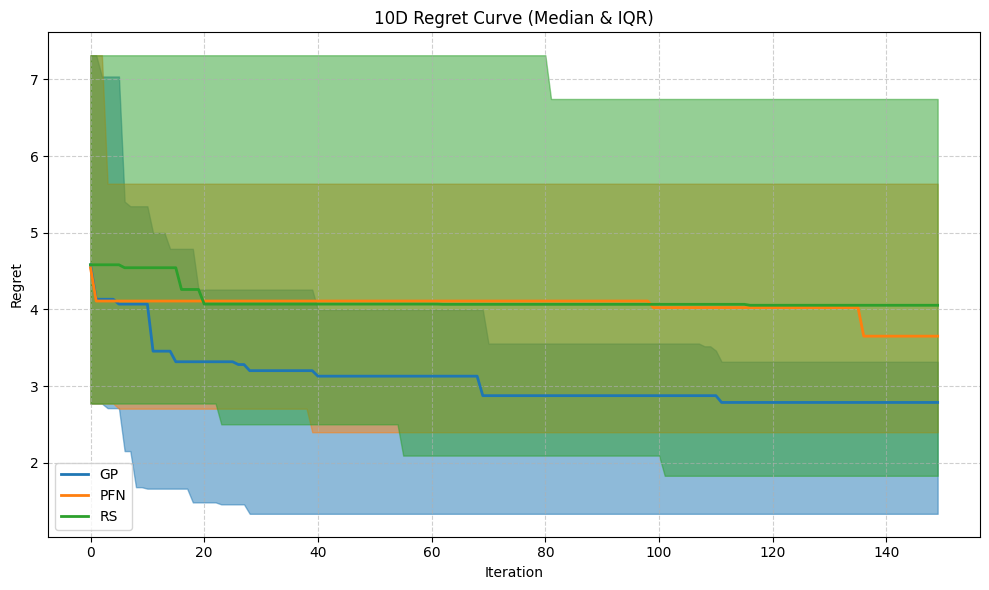

In [42]:
# Set up data dict
regret_data = {
    'GP': regret_10d[0, :, :],
    'PFN': regret_10d[1, :, :],
    'RS': regret_10d[2, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="10D Regret Curve (Median & IQR)")

In [43]:
# Model Error

# Get shape
n_dims, n_methods, n_repeats, N = model_error.shape
print(model_error.shape)

# Separate by dim
err_2d = model_error[0, :, :, :]
err_5d = model_error[1, :, :, :]
err_10d = model_error[2, :, :, :]

torch.Size([3, 2, 21, 150])


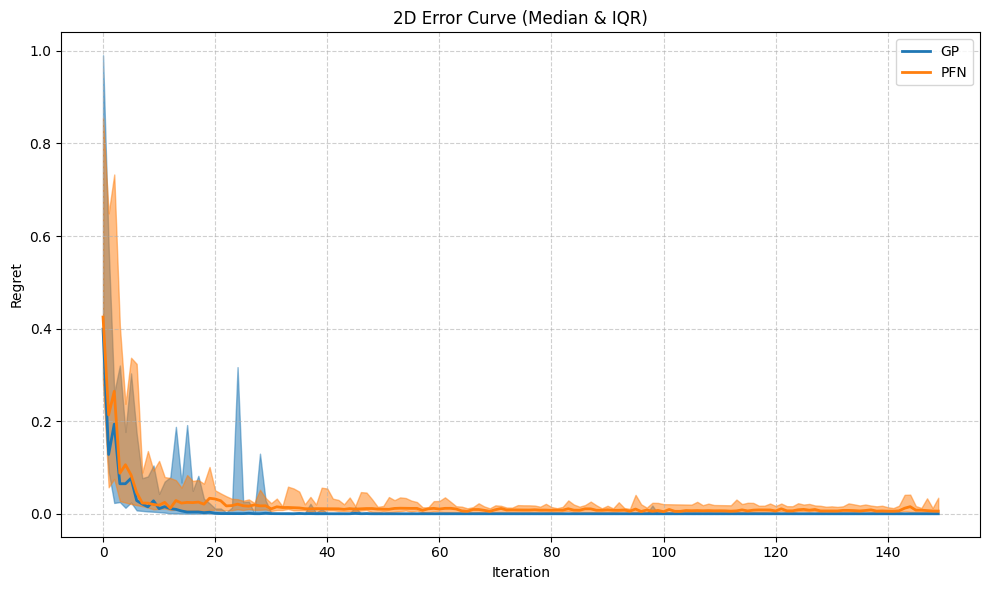

In [44]:
# Set up data dict
regret_data = {
    'GP': err_2d[0, :, :],
    'PFN': err_2d[1, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="2D Error Curve (Median & IQR)")

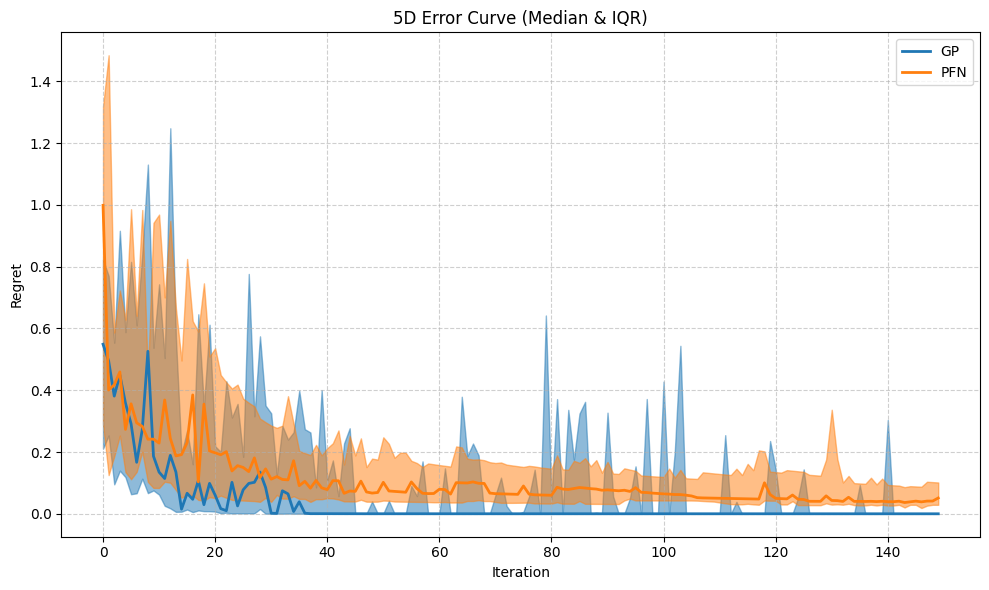

In [45]:
# Set up data dict
regret_data = {
    'GP': err_5d[0, :, :],
    'PFN': err_5d[1, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="5D Error Curve (Median & IQR)")

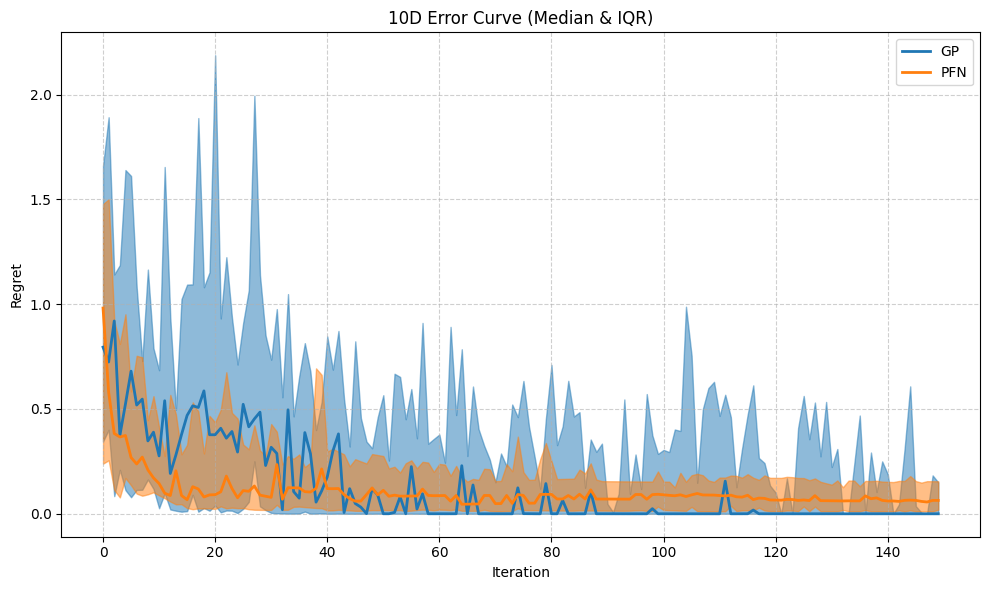

In [46]:
# Set up data dict
regret_data = {
    'GP': err_10d[0, :, :],
    'PFN': err_10d[1, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="10D Error Curve (Median & IQR)")

In [47]:
# Rank curve

# Get shape
n_dims, n_methods, n_repeats, N = rank.shape
print(rank.shape)

# Separate by dim
rank_2d = rank[0, :, :, :]
rank_5d = rank[1, :, :, :]
rank_10d = rank[2, :, :, :]

torch.Size([3, 3, 21, 150])


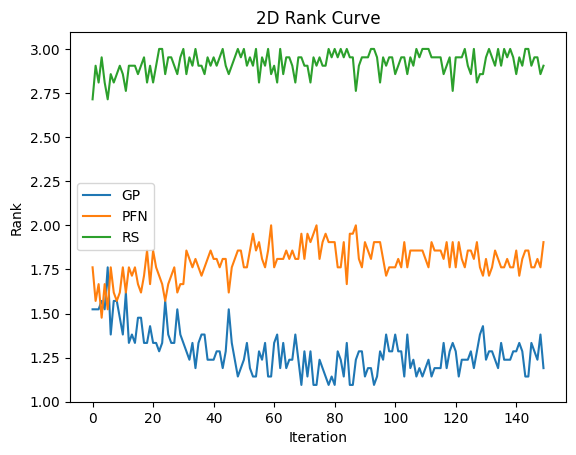

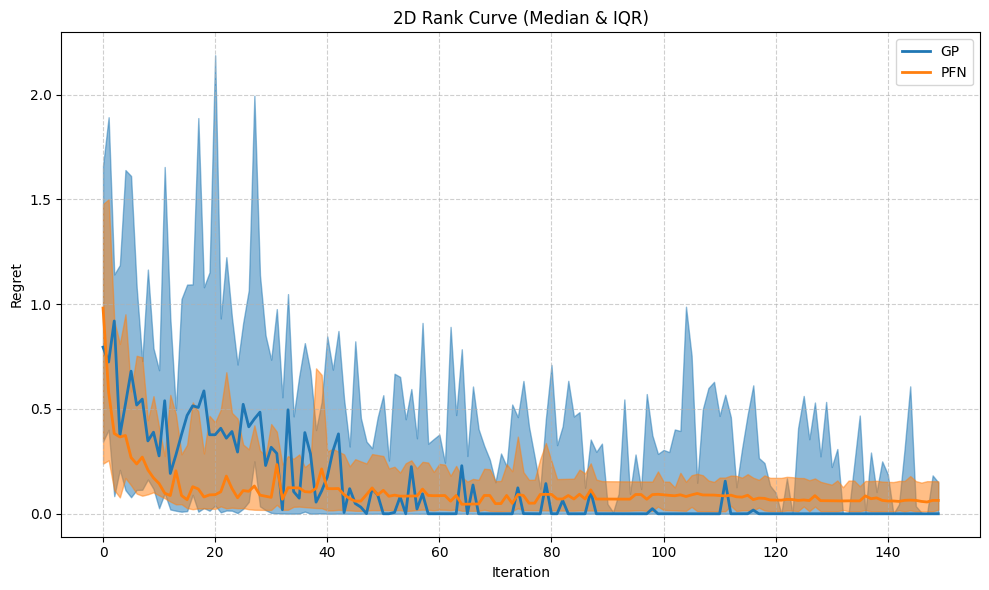

In [48]:
# Plotting 2d results
r_2d_GP = rank_2d[0, :, :]
r_2d_PFN = rank_2d[1, :, :]
r_2d_rs = rank_2d[2, :, :]

# Average across repeats
r_2d_GP_avg = torch.mean(r_2d_GP, dim=0, keepdim=False)
r_2d_PFN_avg = torch.mean(r_2d_PFN, dim=0, keepdim=False)
r_2d_rs_avg = torch.mean(r_2d_rs, dim=0, keepdim=False)

plt.plot(range(N), r_2d_GP_avg, label='GP')
plt.plot(range(N), r_2d_PFN_avg, label='PFN')
plt.plot(range(N), r_2d_rs_avg, label='RS')
plt.xlabel("Iteration")
plt.ylabel("Rank")
plt.title("2D Rank Curve")
plt.legend()
plt.show()

# Set up data dict
rank_data = {
    'GP': rank_2d[0, :, :],
    'PFN': rank_2d[1, :, :],
    'RS': rank_2d[2, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="2D Rank Curve (Median & IQR)")

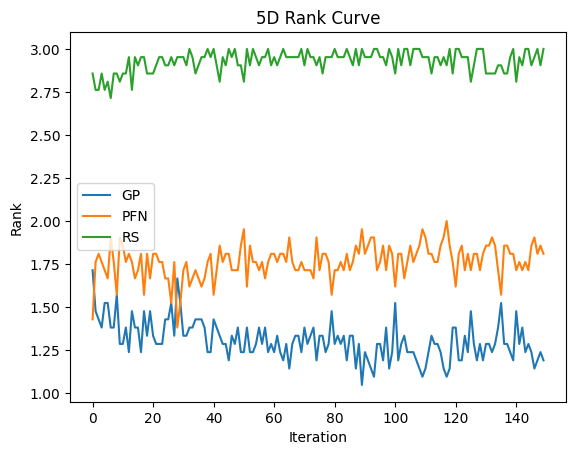

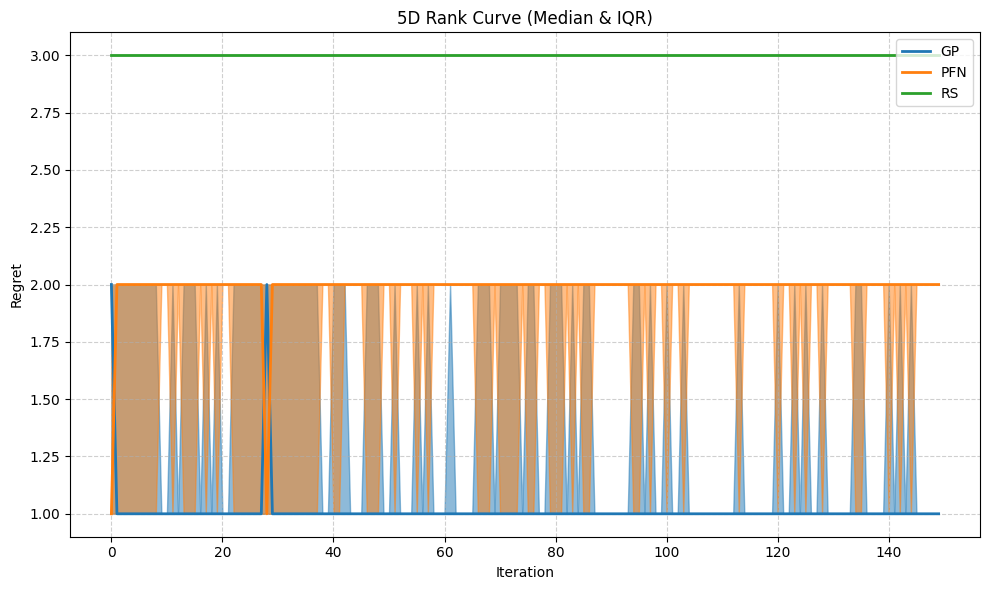

In [49]:
# Plotting 25d results
r_5d_GP = rank_5d[0, :, :]
r_5d_PFN = rank_5d[1, :, :]
r_5d_rs = rank_5d[2, :, :]

# Average across repeats
r_5d_GP_avg = torch.mean(r_5d_GP, dim=0, keepdim=False)
r_5d_PFN_avg = torch.mean(r_5d_PFN, dim=0, keepdim=False)
r_5d_rs_avg = torch.mean(r_5d_rs, dim=0, keepdim=False)

plt.plot(range(N), r_5d_GP_avg, label='GP')
plt.plot(range(N), r_5d_PFN_avg, label='PFN')
plt.plot(range(N), r_5d_rs_avg, label='RS')
plt.xlabel("Iteration")
plt.ylabel("Rank")
plt.title("5D Rank Curve")
plt.legend()
plt.show()

# Set up data dict
regret_data = {
    'GP': rank_5d[0, :, :],
    'PFN': rank_5d[1, :, :],
    'RS': rank_5d[2, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="5D Rank Curve (Median & IQR)")

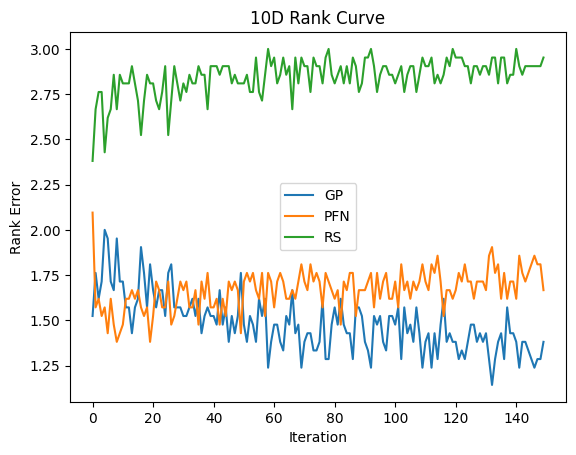

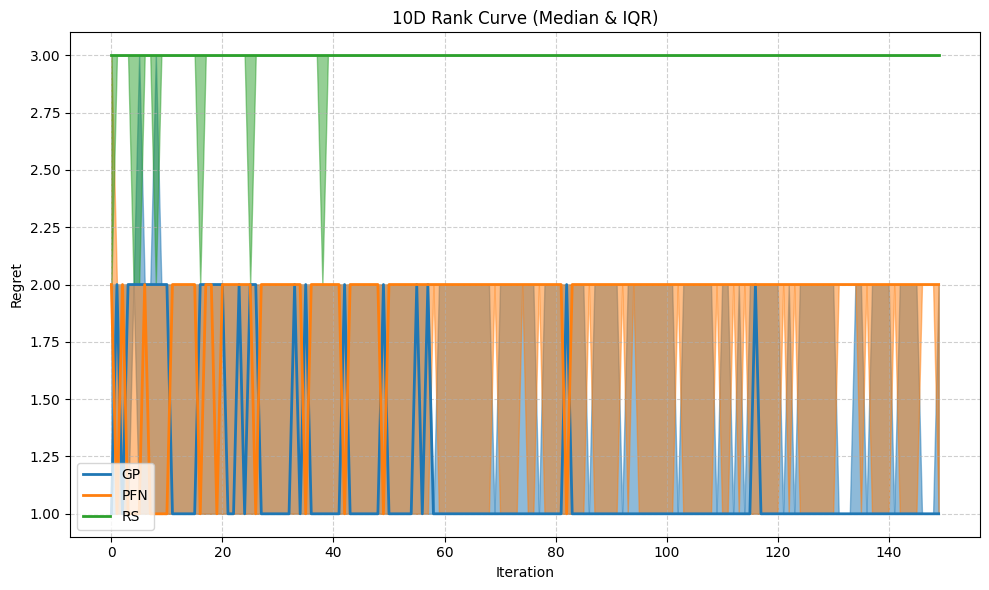

In [50]:
# Plotting 2d results
r_10d_GP = rank_10d[0, :, :]
r_10d_PFN = rank_10d[1, :, :]
r_10d_rs = rank_10d[2, :, :]

# Average across repeats
r_10d_GP_avg = torch.mean(r_10d_GP, dim=0, keepdim=False)
r_10d_PFN_avg = torch.mean(r_10d_PFN, dim=0, keepdim=False)
r_10d_rs_avg = torch.mean(r_10d_rs, dim=0, keepdim=False)

plt.plot(range(N), r_10d_GP_avg, label='GP')
plt.plot(range(N), r_10d_PFN_avg, label='PFN')
plt.plot(range(N), r_10d_rs_avg, label='RS')
plt.xlabel("Iteration")
plt.ylabel("Rank Error")
plt.title("10D Rank Curve")
plt.legend()
plt.show()

# Set up data dict
regret_data = {
    'GP': rank_10d[0, :, :],
    'PFN': rank_10d[1, :, :],
    'RS': rank_10d[2, :, :]
}

# Call the function to generate the plot
plot_distribution(regret_data, title="10D Rank Curve (Median & IQR)")

In [51]:
# Looking at varaince predictions
# var_store = torch.zeros((3, 2, n_repeats, N_iters, n_fns), dtype=torch.float64, device='cpu')
# Store Data (in_dim, method, test_iter, opt_iter, data)

variances = data["var"]
var_2d = variances[0, :, :, :, :]
var_5d = variances[1, :, :, :, :]
var_10d = variances[2, :, :, :, :]

var_2d_GP = var_2d[0, :, :, :]
var_2d_PFN = var_2d[1, :, :, :]

var_2d_GP_avg = torch.quantile(var_2d_GP, 0.50, dim=0)
var_2d_PFN_avg = torch.quantile(var_2d_PFN, 0.50, dim=0)

print(var_2d_GP_avg.shape)

var_5d_GP = var_5d[0, :, :, :]
var_5d_PFN = var_5d[1, :, :, :]

var_5d_GP_avg = torch.quantile(var_5d_GP, 0.50, dim=0)
var_5d_PFN_avg = torch.quantile(var_5d_PFN, 0.50, dim=0)

var_10d_GP = var_10d[0, :, :, :]
var_10d_PFN = var_10d[1, :, :, :]

var_10d_GP_avg = torch.quantile(var_10d_GP, 0.50, dim=0)
var_10d_PFN_avg = torch.quantile(var_10d_PFN, 0.50, dim=0)

torch.Size([150, 1])


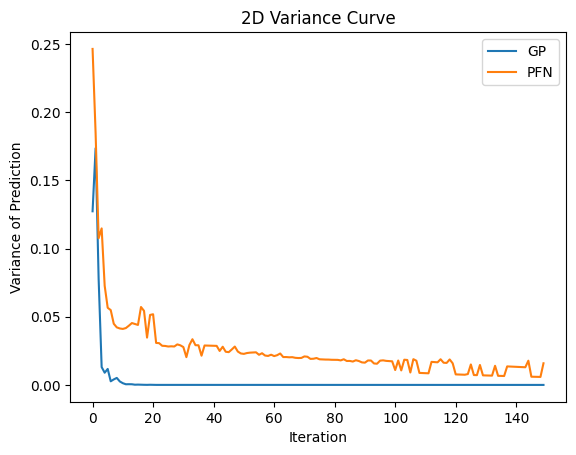

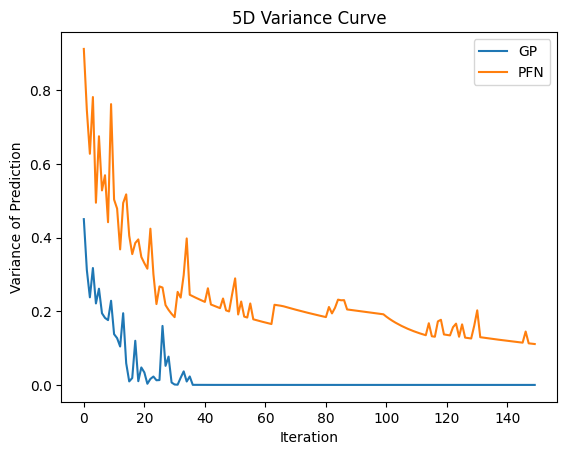

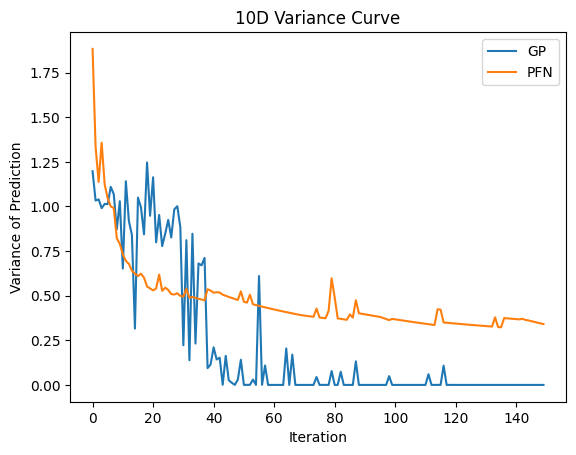

In [52]:
plt.plot(range(N), var_2d_GP_avg, label='GP')
plt.plot(range(N), var_2d_PFN_avg, label='PFN')
plt.xlabel("Iteration")
plt.ylabel("Variance of Prediction")
plt.title("2D Variance Curve")
plt.legend()
plt.show()

plt.plot(range(N), var_5d_GP_avg, label='GP')
plt.plot(range(N), var_5d_PFN_avg, label='PFN')
plt.xlabel("Iteration")
plt.ylabel("Variance of Prediction")
plt.title("5D Variance Curve")
plt.legend()
plt.show()

plt.plot(range(N), var_10d_GP_avg, label='GP')
plt.plot(range(N), var_10d_PFN_avg, label='PFN')
plt.xlabel("Iteration")
plt.ylabel("Variance of Prediction")
plt.title("10D Variance Curve")
plt.legend()
plt.show()

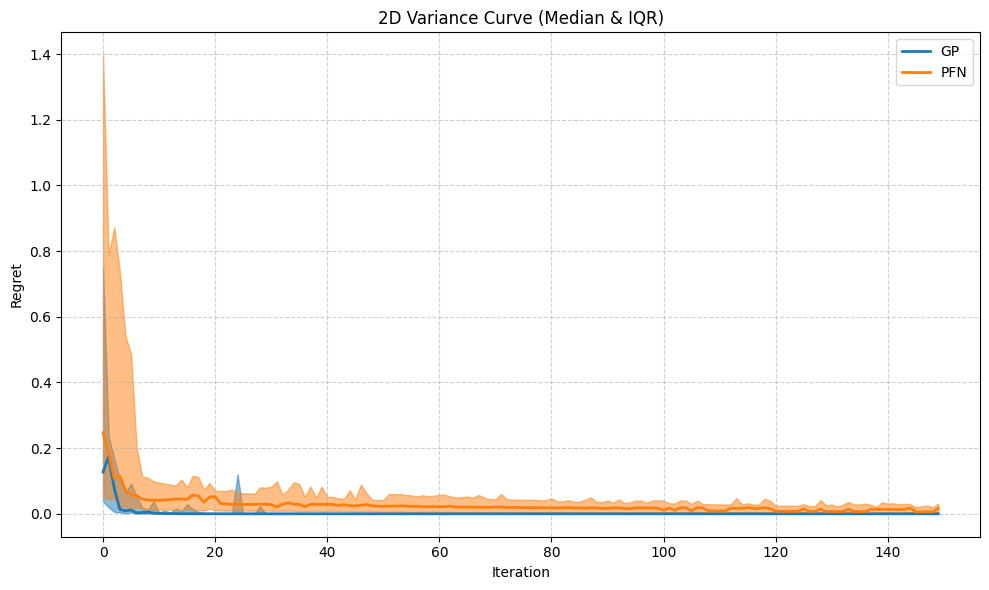

In [53]:
# Set up data dict
var_data = {
    'GP': var_2d[0, :, :].squeeze(dim=-1),
    'PFN': var_2d[1, :, :].squeeze(dim=-1)
}

# Call the function to generate the plot
plot_distribution(var_data, title="2D Variance Curve (Median & IQR)")

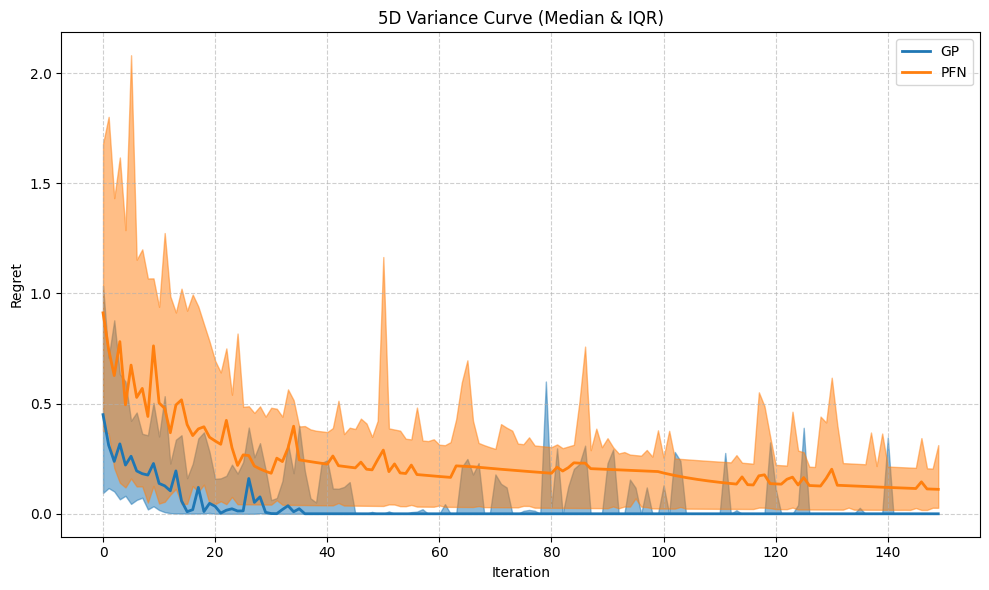

In [54]:
# Set up data dict
var_data = {
    'GP': var_5d[0, :, :].squeeze(dim=-1),
    'PFN': var_5d[1, :, :].squeeze(dim=-1)
}

# Call the function to generate the plot
plot_distribution(var_data, title="5D Variance Curve (Median & IQR)")

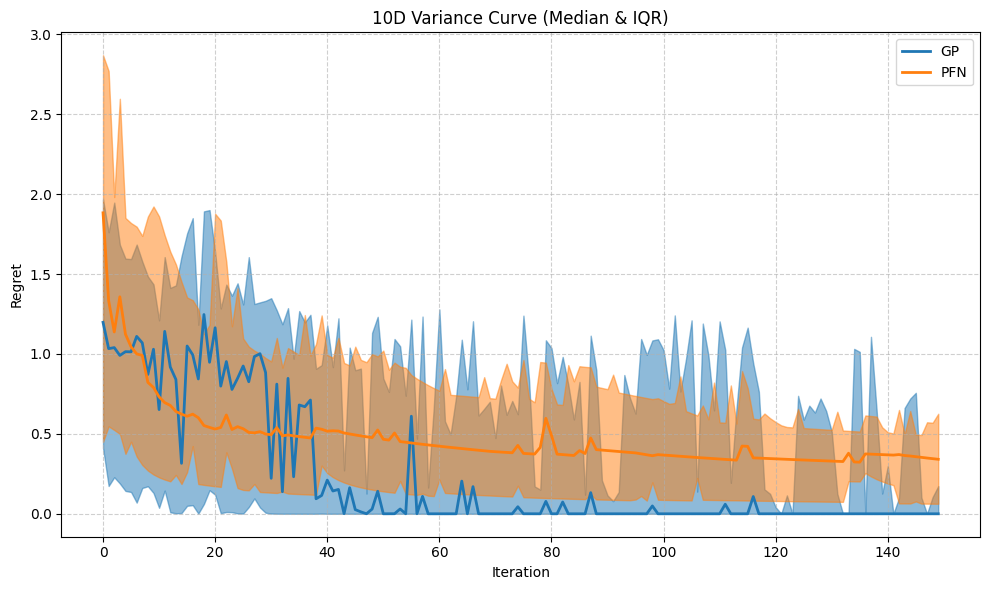

In [55]:
# Set up data dict
var_data = {
    'GP': var_10d[0, :, :].squeeze(dim=-1),
    'PFN': var_10d[1, :, :].squeeze(dim=-1)
}

# Call the function to generate the plot
plot_distribution(var_data, title="10D Variance Curve (Median & IQR)")

In [56]:
# Looking at varaince predictions
# var_store = torch.zeros((3, 2, n_repeats, N_iters, n_fns), dtype=torch.float64, device='cpu')
# Store Data (in_dim, method, test_iter, opt_iter, data)

x_data = data["x_query"]

x_2d = x_data[0]
x_5d = x_data[1]
x_10d = x_data[2]

print(x_2d.shape)

x_2d_GP = x_2d[0, :, :, :]
x_2d_PFN = x_2d[1, :, :, :]

x_2d_GP_avg = torch.quantile(x_2d_GP, 0.50, dim=0)
x_2d_PFN_avg = torch.quantile(x_2d_PFN, 0.50, dim=0)

x_5d_GP = x_5d[0, :, :, :]
x_5d_PFN = x_5d[1, :, :, :]

x_5d_GP_avg = torch.quantile(x_5d_GP, 0.50, dim=0)
x_5d_PFN_avg = torch.quantile(x_5d_PFN, 0.50, dim=0)

x_10d_GP = x_10d[0, :, :, :]
x_10d_PFN = x_10d[1, :, :, :]

x_10d_GP_avg = torch.quantile(x_10d_GP, 0.50, dim=0)
x_10d_PFN_avg = torch.quantile(x_10d_PFN, 0.50, dim=0)

d_2d_GP = torch.zeros((x_10d_GP_avg.shape[0], ), device='cpu')
d_2d_PFN = torch.zeros((x_10d_GP_avg.shape[0], ), device='cpu')

d_5d_GP = torch.zeros((x_10d_GP_avg.shape[0], ), device='cpu')
d_5d_PFN = torch.zeros((x_10d_GP_avg.shape[0], ), device='cpu')

d_10d_GP = torch.zeros((x_10d_GP_avg.shape[0], ), device='cpu')
d_10d_PFN = torch.zeros((x_10d_GP_avg.shape[0], ), device='cpu')

for i in range(x_10d_GP.shape[1]):
    if i > 0:
        d_2d_GP[i] = torch.sum(torch.abs(x_2d_GP_avg[i, :] - x_2d_GP_avg[i - 1, :]))
        d_2d_PFN[i] = torch.sum(torch.abs(x_2d_PFN_avg[i, :] - x_2d_PFN_avg[i - 1, :]))
        
        d_5d_GP[i] = torch.sum(torch.abs(x_5d_GP_avg[i, :] - x_5d_GP_avg[i - 1, :]))
        d_5d_PFN[i] = torch.sum(torch.abs(x_5d_PFN_avg[i, :] - x_5d_PFN_avg[i - 1, :]))
        
        d_10d_GP[i] = torch.sum(torch.abs(x_10d_GP_avg[i, :] - x_10d_GP_avg[i - 1, :]))
        d_10d_PFN[i] = torch.sum(torch.abs(x_10d_PFN_avg[i, :] - x_10d_PFN_avg[i - 1, :]))

torch.Size([3, 21, 150, 2])


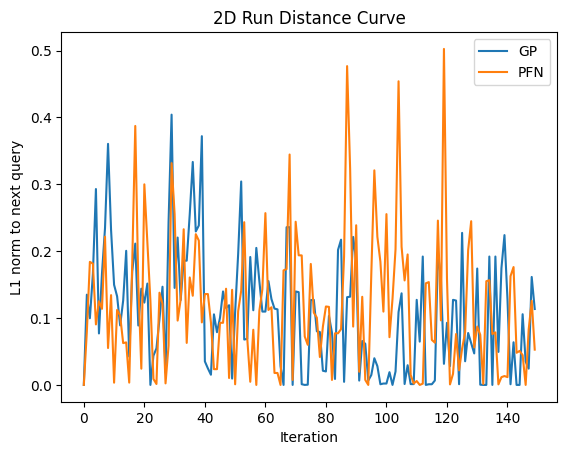

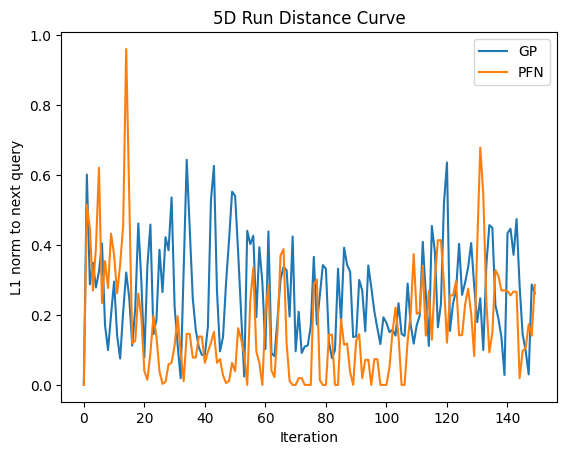

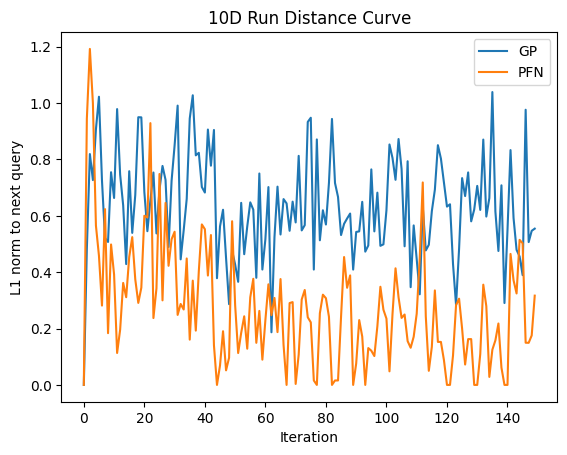

In [57]:
plt.plot(range(N), d_2d_GP, label='GP')
plt.plot(range(N), d_2d_PFN, label='PFN')
plt.xlabel("Iteration")
plt.ylabel("L1 norm to next query")
plt.title("2D Run Distance Curve")
plt.legend()
plt.show()

plt.plot(range(N), d_5d_GP, label='GP')
plt.plot(range(N), d_5d_PFN, label='PFN')
plt.xlabel("Iteration")
plt.ylabel("L1 norm to next query")
plt.title("5D Run Distance Curve")
plt.legend()
plt.show()

plt.plot(range(N), d_10d_GP, label='GP')
plt.plot(range(N), d_10d_PFN, label='PFN')
plt.xlabel("Iteration")
plt.ylabel("L1 norm to next query")
plt.title("10D Run Distance Curve")
plt.legend()
plt.show()

In [25]:
# Query point trajectory through time
# 1000 points in space, query to get space of variances at a couple iterations and plot as a surface
# standardising GP input set for y predictions (look at why) also possibly do for GPs
# Random order for IF
# Beta distribution parameterised by the 5 sets on wikipedia, HS noise bounds between 0.1 and 0.5

In [58]:
# Instantiate pfn
device='cuda'
model_path = pfns4bo.hebo_plus_model
pfn = TransformerBOMethod(torch.load(model_path, weights_only=False), device=device)

In [59]:
# Extract data
train_x_50, train_y_50 = get_training_data(data, dim_idx=0, method_idx=1, repeat_idx=10, iteration=50)
train_x_50 = train_x_50.to(device)
train_y_50 = train_y_50.to(device)

train_x_100, train_y_100 = get_training_data(data, dim_idx=0, method_idx=1, repeat_idx=10, iteration=100)
train_x_100 = train_x_100.to(device)
train_y_100 = train_y_100.to(device)

train_x_150, train_y_150 = get_training_data(data, dim_idx=0, method_idx=1, repeat_idx=10, iteration=150)
train_x_150 = train_x_150.to(device)
train_y_150 = train_y_150.to(device)
bounds = torch.tensor([[0.0, 0.0], [1.0, 1.0]], dtype=torch.float64, device=device)

Evaluating PFN sequentially: 100%|██████████| 1000/1000 [00:14<00:00, 66.99it/s]


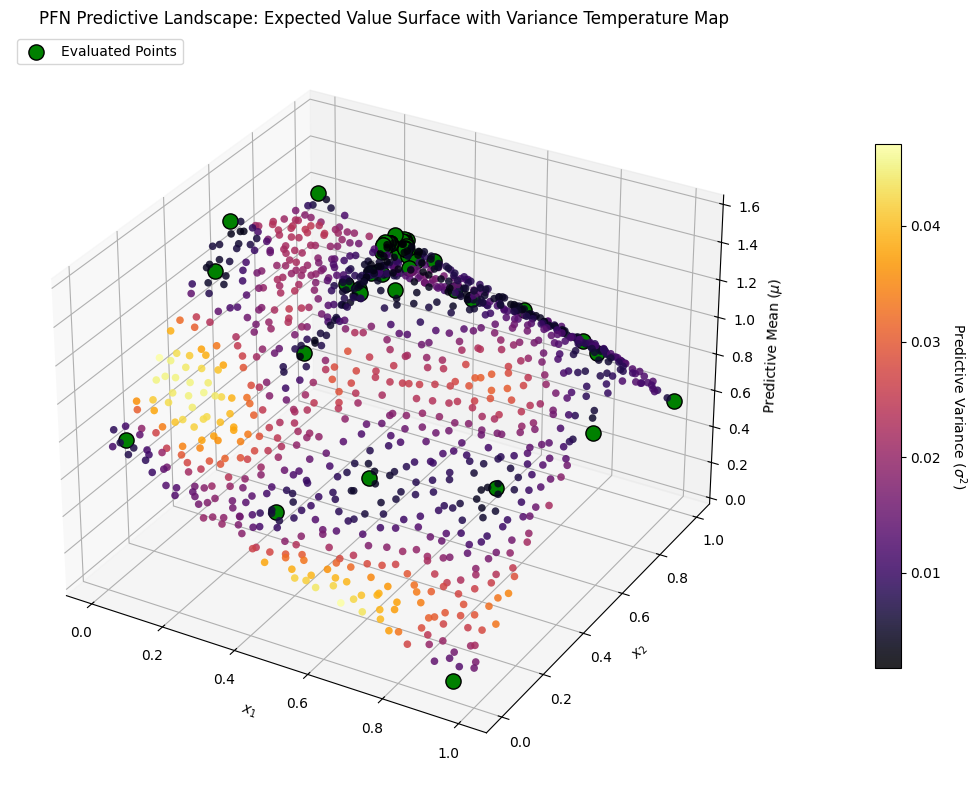

Evaluating PFN sequentially: 100%|██████████| 1000/1000 [00:23<00:00, 42.04it/s]


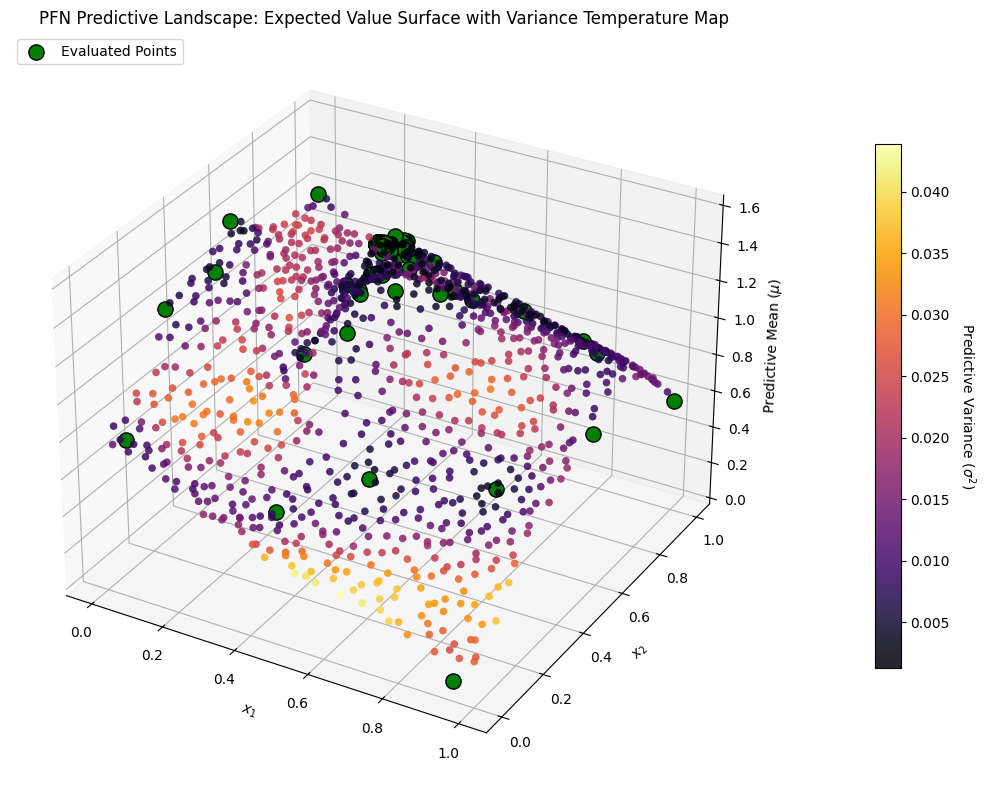

Evaluating PFN sequentially: 100%|██████████| 1000/1000 [00:26<00:00, 37.31it/s]


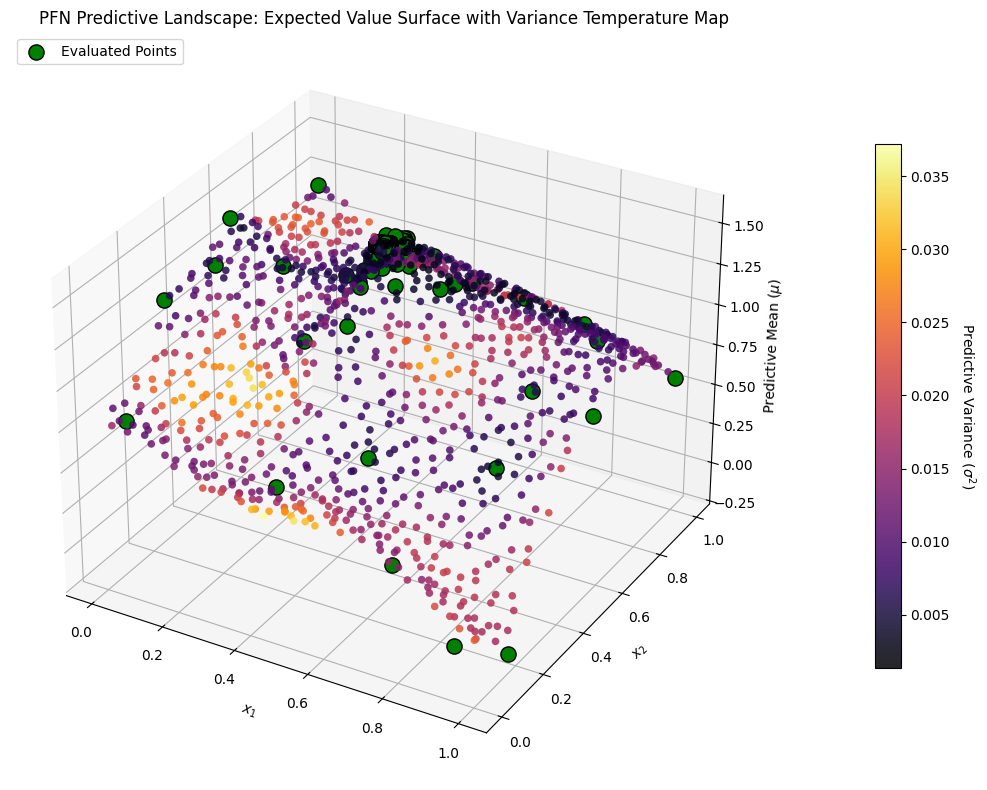

In [60]:
# plot pfn distribution
plot_pfn_variance_surface(pfn, train_x_50, train_y_50, bounds, device=device)
plot_pfn_variance_surface(pfn, train_x_100, train_y_100, bounds, device=device)
plot_pfn_variance_surface(pfn, train_x_150, train_y_150, bounds, device=device)